# Processing solar corona images from total eclipse

This notebook shows full solar eclipse image processing pipeline. Current version works with Nicole Sharp's [data](https://www.cloudynights.com/forums/topic/919153-have-my-eclipse-raws/#findComment-13397853).

First few cells with auxiliar uninteresting stuff

In [1]:
import sys
from pathlib import Path


def v0_package_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "eclipse_v1").is_dir():
        return cwd
    if (cwd / "v1" / "eclipse_v1").is_dir():
        return cwd / "v1"
    raise RuntimeError(
        "Could not find eclipse_v1: set cwd to the `v1` directory or the repo root."
    )


V0_ROOT = v0_package_root()
if str(V0_ROOT) not in sys.path:
    sys.path.insert(0, str(V0_ROOT))

In [2]:
# GPU selection — same defaults as legacy `eda00.py`. Override in the shell, e.g.
#   CUDA_VISIBLE_DEVICES=0 jupyter lab
from eclipse_v1.device import configure_cuda_visible_devices, require_cuda

configure_cuda_visible_devices()
require_cuda()

In [3]:
import os
from pathlib import Path

DATA_ROOT = Path(os.environ.get("EDA00_DATA_ROOT", "/home/slavik/e202602_eclipse/data"))
WORKDIR = Path(os.environ.get("ECLIPSE_V1_WORKDIR", "/home/slavik/tmp/eclipse_v1_run"))
WORKDIR.mkdir(parents=True, exist_ok=True)

PK_STAGE0 = WORKDIR / "v1-stage0.pkl"
PK_STAGE1 = WORKDIR / "v1-stage1.pkl"
PK_STAGE2 = WORKDIR / "v1-stage2.pkl"

## Stage 0 — ingest, moon detection, intra-exposure registration

### 0a — Scan disk → `ImageInfo` list

First scan of images: 100%|██████████| 84/84 [00:15<00:00,  5.28it/s]


We have 84 images, first one is /home/slavik/e202602_eclipse/data/img_0150_53657076894_o.jpg

Example images - one per each exposure time


0.00025s (6 imgs),0.00050s (7 imgs),0.00100s (4 imgs),0.00156s (4 imgs),0.00200s (4 imgs),0.00400s (4 imgs),0.00800s (4 imgs),0.01667s (5 imgs),0.02500s (5 imgs),0.03333s (5 imgs),0.05000s (4 imgs),0.06667s (5 imgs),0.12500s (5 imgs),0.25000s (4 imgs),0.50000s (5 imgs),1.00000s (9 imgs),2.00000s (4 imgs)

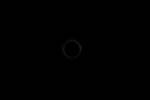
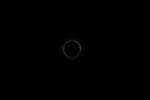
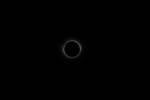
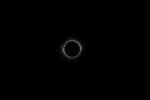
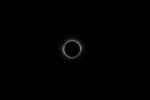
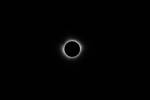
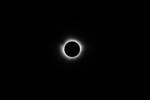
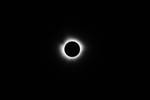
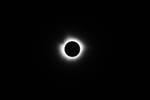
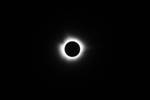
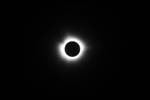
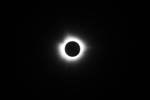
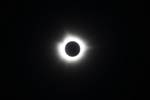
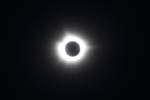
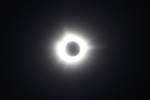
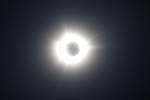
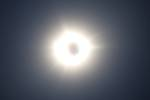

In [4]:
from eclipse_v1 import stage0 as s0
from eclipse_v1.display import plot_exposure_group_thumbnails

# find all images, obtain basic informations about them (size, avg brighness, etc)
image_infos = s0.get_image_infos(DATA_ROOT)
print(f'We have {len(image_infos)} images, first one is {image_infos[0].path}')
# group images by exposure time
exposure_groups = s0.group_by_exposure(image_infos)
print('\nExample images - one per each exposure time')
plot_exposure_group_thumbnails(exposure_groups)

### 0b — Moon detection (loop over every frame)

Our Moon detection is based on assumption that Moon is dark circle surrounded with brighter cloud, where the cloud has sharp circular inner border. One difficulty which makes it nontrivial are protuberances - small blobs much brighter than rest of the corona. They can confuse many naive approaches. And the assumption "sharp circular inner border" is not valid for long exposures where light polute area of Moon disc. Our algorithm fails there, we just detect this failure, erase affected Moon info and replace it with interpolation from successful frames.

Our algorithm is overcomplicated, I don't claim hat it has to be so complex. Anyway, here it is: `stage0_detect_moons()` first downscale image to manageable size, then examine all possible pairs of concentric circles where bigger circle radius is 2px bigger than smaller one, for each circle it compute sum of pixel values around circle boundary, and it pick the circle pair with biggest difference of this quantity between bigger and smaller circle. This gives first approximate of Moon center. With this in hand we move to full resolution, where we split image to 360 radial 1° pie segments from this approximated center. In each segment we identify point with biggest radial gradient. So we have 360 candidate border points. From these points we form 1024 random triplets and for each triplet we find circumcenter. So we have cluster 1024 center candidates. Using AHC library we find dense core of this cluster defined 256 most tightly packed points. We average them obtaining final Moon center. And because for each center candidate we have know the correspnding Moon radius (as we know the triplet of border points which gave us the center candidate), we can average these radii for our 256 best center candidates, obtaining Moon radius estimation.

Looking at the results: shorter exposure yields quite consistent Moon estimation (small `np.std(radii)` within the group). An Moon radious gently decrease with growing exposure time. Of course the Monn doesn't shrink physically, but for longer exposures the light starts to polute moon disk area due to camera imperefections. This phenomenon explode for really long exposures where Moon parameters are entirely off.

In [5]:
# in each image independently, determine moon position and radius
s0.detect_moons(image_infos)
print(f'Exposure groups initial state')
s0.print_exposure_groups_stats(exposure_groups)
# Some moon estimations are just wrong. Identify them and erase them
print(f'Pruning failed Moon estimations')
s0.prune_moon_info_for_radius_outliers(exposure_groups)

Finding moon: 100%|██████████| 84/84 [01:02<00:00,  1.35it/s]

Exposure groups initial state
exposure_time=0.00025 len(group)=6 np.mean(radii)=316.08 np.std(radii)=0.06
exposure_time=0.00050 len(group)=7 np.mean(radii)=316.02 np.std(radii)=0.07
exposure_time=0.00100 len(group)=4 np.mean(radii)=316.03 np.std(radii)=0.06
exposure_time=0.00156 len(group)=4 np.mean(radii)=315.83 np.std(radii)=0.06
exposure_time=0.00200 len(group)=4 np.mean(radii)=315.75 np.std(radii)=0.07
exposure_time=0.00400 len(group)=4 np.mean(radii)=315.63 np.std(radii)=0.05
exposure_time=0.00800 len(group)=4 np.mean(radii)=315.19 np.std(radii)=0.29
exposure_time=0.01667 len(group)=5 np.mean(radii)=314.37 np.std(radii)=0.19
exposure_time=0.02500 len(group)=5 np.mean(radii)=313.94 np.std(radii)=0.05
exposure_time=0.03333 len(group)=5 np.mean(radii)=313.75 np.std(radii)=0.34
exposure_time=0.05000 len(group)=4 np.mean(radii)=313.42 np.std(radii)=0.16
exposure_time=0.06667 len(group)=5 np.mean(radii)=313.19 np.std(radii)=0.15
exposure_time=0.12500 len(group)=5 np.mean(radii)=312.51 n

### 0c — Interpolate missing positions; set position uncertainty

In [6]:
interp = s0.interpolate_missing_moons(image_infos, exposure_groups)
s0.set_moon_position_std(image_infos, exposure_groups, interp)

moon_position_uncertainty_px=2.04


### 0d — Intra-exposure registration: all ordered pairs per group (slow)

Slowest part of pipeline, registration (alignment) of images within each exposure group. It's slow because we are computing alignment of each image pair within group, distinguishing even order (A to B computed seprately from B to A). And the registration is nontrivial because we need to align corona (blurry), not the Moon border which is nice and sharp, but is significantly moving wrt our real target - the corona.

Our regisrtation algorithm does gridsearch of transformations of image B which would lead to good alignment with image A. For scoring 'goodness' of alignment we mask out Moon from both images, filter out lowfeq tangential components, clip some extremely high intensities (protuberances), and  use mean absolute error. Cliping of protuberance intensities is because protuberances evolve quickly. We clip the intensities because we still want to use protuberances as landmarks, but we dont want them to dominate the alignment score. 

Regarding output: for each exposure group you see progress of its processing and once it's done, there is output like
```
Check 1: ij mean=0.1423 max=0.5546  rot mean=0.0104 max=0.0781
Check 2: ij mean=0.2621 max=1.1061  rot mean=0.0339 max=0.0781
```
Its doing two checks. Check 1 takes all registration pairs of images `A`, `B` and checks how much is found alignment transformation `A->B` consistent with `B->A`. It outputs stats of found discrepancy in pixels, first for translation (in our example values `mean=0.1423 max=0.5546`) and then for rotation component of found transform (in our example `rot mean=0.0104 max=0.0781`). Check 2 does similar discrepance check between composed transform `A->B, B->C` and direct `A->C` for all triplets in exposure group.

In [7]:
reg = s0.register_intra_exposure_pairs(exposure_groups)
s0.save_pickle(exposure_groups, reg, PK_STAGE0)

Doing check for exposure time 0.00025


Registration pairs: 100%|██████████| 30/30 [10:33<00:00, 21.12s/it]


  Check 1: ij mean=0.1367 max=0.5871  rot mean=0.0208 max=0.0781
  Check 2: ij mean=0.1965 max=0.9576  rot mean=0.0299 max=0.0781
Doing check for exposure time 0.0005


Registration pairs: 100%|██████████| 42/42 [13:37<00:00, 19.46s/it]


  Check 1: ij mean=0.1612 max=0.7181  rot mean=0.0112 max=0.0781
  Check 2: ij mean=0.1696 max=0.7618  rot mean=0.0123 max=0.0781
Doing check for exposure time 0.001


...

Registration pairs: 100%|██████████| 72/72 [29:37<00:00, 24.68s/it]


  Check 1: ij mean=0.3178 max=2.2628  rot mean=0.0043 max=0.0781
  Check 2: ij mean=0.4524 max=3.3051  rot mean=0.0158 max=0.1562
Doing check for exposure time 2.0


Registration pairs: 100%|██████████| 12/12 [04:41<00:00, 23.46s/it]

  Check 1: ij mean=0.1331 max=0.7993  rot mean=0.0000 max=0.0000
  Check 2: ij mean=0.3828 max=0.4330  rot mean=0.0000 max=0.0000
Saved /home/slavik/tmp/eclipse_v1_run/v1-stage0.pkl (exposure_groups, reg)


PosixPath('/home/slavik/tmp/eclipse_v1_run/v1-stage0.pkl')

## Stage 1 — prune stacks, global pose fit per exposure

### 1a — Pruning of images within exposure groups

It has two steps. First we throw away images with average brightness too different from rest of the group. Then we remove images, which contribute most to inconsistent registrations (with too big difference between composed `A->B, B->C` and direct `A->C`).


In [8]:
import torch
from eclipse_v1 import stage1 as s1

exposure_groups, reg = s1.load(PK_STAGE0)
s1.prune_groups(exposure_groups, reg)

prune_brightness_outliers: exp=1.00000 removed image (idx 8) img_0227_53655846522_o.jpg brightness=0.495798 group_std change when removed: 0.075797 -> 0.020027


### 1b — Optimization loop (one solve per exposure time)

So far we have pairwise registration transformations between image pairs within each group. We need to figure out some absolute placement of the images withing group, which will be as consistent as possible with these known pairwise deltas. It's what the `optimize_poses_and_debug` does (in each group separately). It first builds some initial guess, starting from closest image pair and adding other images iterativly, in each step choosing the closest image to already placed. Then it just optimize global placement, minimizing the discrepancy between pairwise transforms computed from the global placement and pairwise transforms required by optimal pair registrations. Apart from solving the placement, it save some debug images and animations in `${WORKDIR}/v1-stage1_debugimg*`

In [9]:
device = torch.device("cuda")
opt_results = s1.optimize_poses_and_debug(
    exposure_groups, reg, device, debug_img_dir=WORKDIR
)


  exp=0.00025: initial loss_shift=2.027815 loss_rot=0.000015


angles: 100%|██████████| 50000/50000 [00:18<00:00, 2640.57it/s]


  exp=0.00025: phase1 loss_shift=2.031014 loss_rot=0.000007


shifts: 100%|██████████| 50000/50000 [00:24<00:00, 2038.06it/s]


  exp=0.00025: final   loss_shift=1.237038 loss_rot=0.000007

  exp=0.0005: initial loss_shift=3.220151 loss_rot=0.000006


...

  exp=0.5: final   loss_shift=0.302568 loss_rot=0.000000

  exp=1.0: initial loss_shift=23.231812 loss_rot=0.000000


shifts: 100%|██████████| 50000/50000 [00:20<00:00, 2436.30it/s]


  exp=1.0: final   loss_shift=2.604374 loss_rot=0.000000

  exp=2.0: initial loss_shift=2.250363 loss_rot=0.000000


shifts: 100%|██████████| 50000/50000 [00:20<00:00, 2435.27it/s]


  exp=2.0: final   loss_shift=0.907339 loss_rot=0.000000


Inspect carefuly debug images. Click them to see full resolution. The images ar animations. You should see Sun-related features (protuberances, corona) static and Moon jumping in front of them. If the Sun is not aligned perfectly, then the processing pipeline failed for your data and you have to debug it. On images with longre exposures, Sun features are not so well localized, but you start to be able to see stars. Stars are good enough to judge registration.

In [10]:
from eclipse_v1.display import symlink_stage1_debug_anim_gifs, display_clickable_stage1_debug_img_grid
symlink_stage1_debug_anim_gifs(WORKDIR)
display_clickable_stage1_debug_img_grid(columns=8, width=128)

In [11]:
s1.save_pickle(PK_STAGE1, exposure_groups, reg, opt_results)

Saved /home/slavik/tmp/eclipse_v1_run/v1-stage1.pkl (exposure_groups, reg, opt_results: abs_xy + abs_angle_t per exposure)


PosixPath('/home/slavik/tmp/eclipse_v1_run/v1-stage1.pkl')

## Stage 2 — full-res stack mean per exposure, then cross-exposure chain

### 2a — Load pickled data, compute moon parameters median per exposure group

In [12]:
from eclipse_v1 import stage2 as s2

exposure_groups, _reg, opt_results = s2.load(PK_STAGE1)
moon_by_exp, exposure_times_sorted = s2.moon_median_table(exposure_groups)

Loaded 17 exposure groups; moon_by_exp computed.


### 2b — Full-resolution averaged image per exposure

Use the registration parameters we computed in previous steps and compute single averaged image per each exposure group.

In [13]:
import torch
device = torch.device("cuda")
avg_images = s2.fullsize_averages(
    exposure_groups, exposure_times_sorted, opt_results, device
)

Averaged images: 100%|██████████| 17/17 [00:27<00:00,  1.60s/it]

Built 17 averaged images (full size).


### 2c — Consecutive exposure pairs: gamma + cross registration

For each pair of consecutive exposures we compute two quantities needed to perform registration (alignment):

1) `gamma`, exponent used to transform pixel values between images with different exposures

2) registraction (alignment) transformation.

Once we know `gamma`, we can convert pixel values between the two images and the transformation then can be computed almost the same way as we did it in previous stages (only we have to avoid pixels which are saturated in the image with longer exposure). But to compute `gamma` (which we do by just gridsearch with MAE as objective), one needs to know how to align the two images. So we do 1) and 2) in two iterations, refining each of them using output of the another.

In [14]:
pairs_results = s2.cross_exposure_consecutive_pairs(
    exposure_times_sorted, avg_images, moon_by_exp, device, pair_gif_dir=WORKDIR
)

t0=0.00025 t1=0.00050 gamma=1.1660 -> /home/slavik/tmp/eclipse_v1_run/v1-stage2_pair_0.00025_0.00050_gamma1.1660.gif
t0=0.00050 t1=0.00100 gamma=1.1406 -> /home/slavik/tmp/eclipse_v1_run/v1-stage2_pair_0.00050_0.00100_gamma1.1406.gif
t0=0.00100 t1=0.00156 gamma=1.1094 -> /home/slavik/tmp/eclipse_v1_run/v1-stage2_pair_0.00100_0.00156_gamma1.1094.gif
t0=0.00156 t1=0.00200 gamma=1.2500 -> /home/slavik/tmp/eclipse_v1_run/v1-stage2_pair_0.00156_0.00200_gamma1.2500.gif
t0=0.00200 t1=0.00400 gamma=1.1523 -> /home/slavik/tmp/eclipse_v1_run/v1-stage2_pair_0.00200_0.00400_gamma1.1523.gif
t0=0.00400 t1=0.00800 gamma=1.1465 -> /home/slavik/tmp/eclipse_v1_run/v1-stage2_pair_0.00400_0.00800_gamma1.1465.gif
t0=0.00800 t1=0.01667 gamma=1.2012 -> /home/slavik/tmp/eclipse_v1_run/v1-stage2_pair_0.00800_0.01667_gamma1.2012.gif
t0=0.01667 t1=0.02500 gamma=0.9863 -> /home/slavik/tmp/eclipse_v1_run/v1-stage2_pair_0.01667_0.02500_gamma0.9863.gif
t0=0.02500 t1=0.03333 gamma=1.3906 -> /home/slavik/tmp/eclipse_v

Create debug gifs, similarly as we did in previous stage. Inspect, if registration between exposure pairs worked.

In [15]:
from eclipse_v1.display import symlink_stage2_pair_gifs, display_clickable_stage2_pair_gif_grid
symlink_stage2_pair_gifs(WORKDIR)
display_clickable_stage2_pair_gif_grid(columns=8, width=128)

Pickle results of this stage

In [16]:

s2.save_pickle(PK_STAGE2, pairs_results)

Saved /home/slavik/tmp/eclipse_v1_run/v1-stage2.pkl (cross_reg, gamma_by_pair).


PosixPath('/home/slavik/tmp/eclipse_v1_run/v1-stage2.pkl')

## Stage 3 — merge, radial tone, patch FFT sharpen, RGB

First we load what we saved from previous stages and use it to build sinlge image, which contains data from all the exposures. In previous stages we obtained registrations transforms and gammas which let us to convert pixel intensities fro mdifferent exposures to the same scale. So we do per-pixel weighted average of exposures. The average is 'weighted' because for each pixel some exposures are overburn, some are almost zero, and some provide somemeaningful reliable values.

In [17]:
from eclipse_v1.stage3 import (
    Stage3Context,
    build_per_exposure_averages,
    crop_and_save_composite,
    fft_unsharp_and_save,
    load_inputs,
    radial_normalize_display,
    rgb_vignette_and_radial_pickle,
    warp_merge_to_composite,
)
from eclipse_v1.display import symlink_and_display_clickable

ctx = Stage3Context(workdir=WORKDIR)
load_inputs(ctx)
# we build per exposure avgs again as we didnt saved them in previous stages
build_per_exposure_averages(ctx)
# single image from all the exposures
warp_merge_to_composite(ctx)
# crop the borders which are not covered enough
crop_and_save_composite(ctx)
symlink_and_display_clickable(ctx, 'v1-stage3_composite_preview.png')

Reference exposure t_ref=0.001, moon_ref (i,j,r)=(1965.3612785905896, 2884.534129877167, 316.0292134528131)
cross_reg pairs: 16, gamma_by_pair: 16


Averaged images: 100%|██████████| 15/15 [00:24<00:00,  1.61s/it]


Built 15 averaged images.
Reference shape H=4000, W=6000
Exposures in chain: 15


Warp and merge: 15it [00:06,  2.27it/s]


Composite shape (4000, 6000), dtype float64
Crop bounds rows [21,3979], cols [18,5973]; shape (3959, 5956)
Saved /home/slavik/tmp/eclipse_v1_run/v1-stage3_composite.npy (float64), /home/slavik/tmp/eclipse_v1_run/v1-stage3_composite_preview.png


The composite data already contains all the corona details through the whole image, but because huge dynamic range, they are not visible in image. Far from Sun they are too dimm, near the sun they are too bright. We have to somehow normalize them, to convert them into some perceivable values for all radius values. Simplest approach is to for each distance from sun center, compute mean and std of pixels at this distance, and use them to normalize pixel vaues at this distance. The actual formula I'm using is more elaborated but there is no science behind it. I just arrived by trial-error to something what looks acceptable for me. So the actual procedure is this:

To make implementation simpler, we work in polar coordinates with zero in Sun center.

For the bigger radii (corners of the image), we dont have pixels for all thetas. We need them to compute means around circumference, so we have simple intrapolation / extrapolation to compute them. So we can compute means. The actual normalization formula work as piecewise linear mapping `[mean/2, mean] -> [0, 0.4]` and `[mean, 2*mean] -> [0.4, 1]`. And in fact we compute two versions of it. In the first, mean is taken around whole circumference. In the second, mean is taken on sliding window 15% of circumference around the pixel we normalize. We average these two normalized values. Then we do one more step which Claude named 'radially-adaptive background subtraction'. The idea is to take some small percentile of pixels value as background intensity and subtract it, converting pixels with this (and lower) values to black. The percentile is radius dependent, varying linearly from 0.01% at sun center to 3% in image corners. 

In [18]:
radial_normalize_display(ctx)
symlink_and_display_clickable(ctx, "v1-stage3_radial_normalize.png")

100%|██████████| 3489/3489 [00:01<00:00, 2712.98it/s]


Saved /home/slavik/tmp/eclipse_v1_run/v1-stage3_radial_normalize.png


So here we finally see the corona but the image is blured. There is classical vintage algorithm for sharpening called Unsharp Mask. For image `x` it first makes its blurred copy `b = gaussian_blur(x, sigma)` and then it compute sharpened image as `y = x + c * (x - b)` where `c` is some scalar constant (strength). But it enhance noise as well as desired structure. To address this problem, I developed slightly elaborated version.

The bluring step is almost standard with one modification. Near the Moon boundary, bluring kernel is modified to prevent the moon boundary from geting blured radially. Once we have blured version, we compute the difference original minus blurred and then we try to enhance linear structures in this difference. To this end we process it in overlaping patches 256x256 pixels. In each patch we compute FFT. Then we use two facts: 1) the interesting structures in image tend to have big amplitudes in spectrum (or at least some of the amplitudes). 2) linear structures in image manifest in spectrum as radial lines. So, to exploit 1), we compute some amplitude threshold (specified by percentile) and we subtract the threshold from all amplitudes (and then clamp to prevent negative amplitudes). And before doing this, we exploit 2) to enhance the spectrum: we modify amplitudes, adding to each of them median along some line segment pointing towards spectrum plane center (which enhance radial lines in spectrum). 

This is main principle giving us enhanced difference wrt blurred version. We use this difference in standard unsharp mask way. Two more details: First, because we know where moon boundary (which is very sharp linear structure) is located in image, we can in each tile which contains it give its spectrum some special handling, keeping it separately from spectrum of corona features. Second, we are doing all this unsharp mask magic for 3 different values of sigma and strength, combining the results.

In [19]:
fft_unsharp_and_save(ctx)
symlink_and_display_clickable(ctx, 'v1-stage3_radial_normalize_sharpen_fft_smoothed_diff.png')

FFT-smooth diff sigma=8.0: 100%|██████████| 463/463 [04:25<00:00,  1.74it/s]


Saved /home/slavik/tmp/eclipse_v1_run/v1-stage3_radial_normalize_sharpen_fft_smoothed_diff.png


The image is now much sharper but it comes at a expense: we introduced some artifacts. They are most notable at the doublestar which our trickery changed from this

![doublestar0](doublestar0.png)

to this

![doublestar1](doublestar1.png)

But the whole image with all the details is so beutiful, that I chose to accept the artifacts.

Finally, we apply some false colors and darkening towards border, to make it nicer

In [20]:
rgb_vignette_and_radial_pickle(ctx)
symlink_and_display_clickable(ctx, 'v1-stage3_rgb_rescaled.png')

Saved /home/slavik/tmp/eclipse_v1_run/v1-stage3_rgb_rescaled.png


### After run: patch count on actual composite crop

## Quick look (optional)

---

**One-shot alternative** (same math, fewer visible steps): `s0.run(DATA_ROOT, PK_STAGE0)`, `s1.run(...)`, `s2.run(...)`, and either `run(WORKDIR)` or the stepped `Stage3Context` + `stage3 steps` calls above.